![Johnson & Johnson MedTech Logo](https://raw.githubusercontent.com/Forage-Simulations/Johnson-Johnson-Robotics-Controls/main/github_assets.png)


# Robotic Arm Design Simulation

### Objective
This notebook helps simulate the impact of design modifications on a robotic arm’s performance. You will:

- Test design modifications for improving response time and durability.
- Input efficiency and reinforcement factors to assess their impact.
- Visualize simulation results for response time and durability metrics.
- Document findings to support your design proposal.

### Instructions
1. **Run Setup Cells**: Load libraries and define functions necessary for simulations.
2. **Input Factors**: Enter efficiency and reinforcement factors to simulate improvements.
3. **Analyze Results**: Compare original and improved metrics using the visual output.
4. **Document Findings**: Record your observations to support your design proposal.

Ensure you use the **Design Proposal Template** to document your findings.


In [2]:
# Import required libraries
import numpy as np  # For numerical calculations
import matplotlib.pyplot as plt  # For data visualization

# Ensure the necessary libraries are installed
try:
    import numpy
    import matplotlib
except ImportError as e:
    print(f"Missing library: {e}. Please install it using 'pip install numpy matplotlib'.")


In [3]:
# Function to simulate response time improvements
def simulate_response_time(base_time, efficiency_factor):
    """Calculate the new response time based on efficiency improvements."""
    return base_time * (1 - efficiency_factor)

# Function to simulate durability improvements
def simulate_durability(base_durability, reinforcement_factor):
    """Calculate the new durability score based on reinforcement."""
    return base_durability + (base_durability * reinforcement_factor)


In [4]:
# Example Base Metrics
base_response_time = 0.20  # in seconds
base_durability = 75       # durability score out of 100

# User Inputs with Validation
while True:
    try:
        efficiency_factor = float(input("Enter efficiency improvement factor (between 0 and 1, e.g., 0.15 for 15%): "))
        if 0 <= efficiency_factor <= 1:
            break
        else:
            print("Please enter a value between 0 and 1.")
    except ValueError:
        print("Invalid input. Please enter a numerical value.")

while True:
    try:
        reinforcement_factor = float(input("Enter durability reinforcement factor (between 0 and 1, e.g., 0.10 for 10%): "))
        if 0 <= reinforcement_factor <= 1:
            break
        else:
            print("Please enter a value between 0 and 1.")
    except ValueError:
        print("Invalid input. Please enter a numerical value.")


Enter efficiency improvement factor (between 0 and 1, e.g., 0.15 for 15%): 0.15
Enter durability reinforcement factor (between 0 and 1, e.g., 0.10 for 10%): 0.10


In [5]:
# Simulations
new_response_time = simulate_response_time(base_response_time, efficiency_factor)
new_durability = simulate_durability(base_durability, reinforcement_factor)

# Output Results
print("\nSimulation Results:")
print(f"Original Response Time: {base_response_time} seconds")
print(f"New Response Time: {round(new_response_time, 3)} seconds")
print(f"Original Durability Score: {base_durability}")
print(f"New Durability Score: {round(new_durability, 2)}")



Simulation Results:
Original Response Time: 0.2 seconds
New Response Time: 0.17 seconds
Original Durability Score: 75
New Durability Score: 82.5


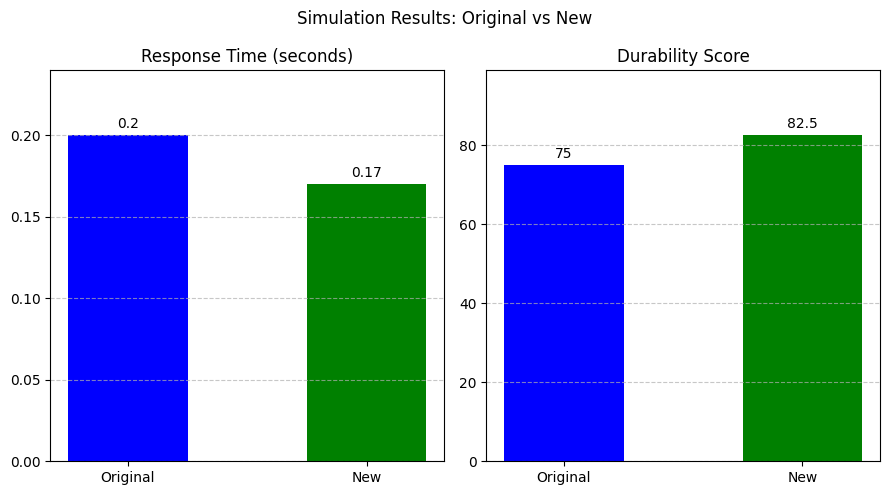

In [6]:
# Visual Feedback
# Response time (~0.2 s) and durability (~75) differ by orders of magnitude,
# so each metric gets its own axis; on a shared axis the response-time bars are invisible.
metrics = ["Response Time (seconds)", "Durability Score"]
original_values = [base_response_time, base_durability]
new_values = [new_response_time, new_durability]

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax, metric, orig, new in zip(axes, metrics, original_values, new_values):
    bars = ax.bar(["Original", "New"], [orig, new], color=["blue", "green"], width=0.5)
    ax.bar_label(bars, labels=[f"{orig:g}", f"{round(new, 3):g}"], padding=3)
    ax.set_title(metric)
    ax.set_ylim(0, max(orig, new) * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.suptitle("Simulation Results: Original vs New")
plt.tight_layout()
plt.show()

### Observations and Results

Record your observations from the simulation below:

#### Initial Metrics:
- Response Time: 0.20 seconds
- Durability Score: 75

#### Improved Metrics:
Inputs used: efficiency factor 0.15 (15%), reinforcement factor 0.10 (10%).
- Response Time: 0.17 seconds
- Durability Score: 82.5

#### Key Insights:
1. **Efficiency factor and response time:** The efficiency factor reduces response time in proportion (`0.20 x (1 - 0.15) = 0.17 s`). A 15% improvement saves 0.03 s per command, and a larger factor gives a proportionally faster arm.
2. **Reinforcement factor and durability:** The reinforcement factor raises the durability score in proportion (`75 x (1 + 0.10) = 82.5`), a 10% gain of 7.5 points. A larger factor gives a higher score.
3. **Trade-offs:** In this simulation the two factors are independent, so improving one does not cost anything in the other. In a real arm, reinforcement adds mass or stiffness that would usually slow the response, so both could not be pushed to large values at once. The model also does not cap durability at 100, so a reinforcement factor above about 0.33 would give an unrealistic score.
4. **Are the improvements significant?** They are moderate. A 15% faster response and a 10% durability gain are within the suggested 10-15% starting range, so they are meaningful but not dramatic. Whether 0.03 s matters depends on the real latency requirement for surgical control, which this simulation does not define. If a larger gain is needed, the factors can be raised and the simulation re-run, keeping the trade-offs above in mind.
5. **Reading the chart:** Response time and durability are on very different scales (about 0.2 versus 75), so the chart plots each metric on its own axis. On a shared axis the response-time bars would be nearly invisible.

#### Conclusion:
Combining a 15% efficiency improvement with a 10% reinforcement reduces response time from 0.20 s to 0.17 s and raises durability from 75 to 82.5. Both results come from a simple proportional model with simulated inputs. Next steps: add a trade-off term (for example, reinforcement increasing response time), cap the durability score at 100, and validate the factors against physical test data before proposing them in the design proposal.
